# Feature engineering

In [ ]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the single complete dataset
df = pd.read_csv('final_df.csv')

print(f"Original Data shape: {df.shape}")

Original Data shape: (1827, 36)


In [32]:
# Cell 2: Data Preprocessing, Averaging Weather, and formatting Dates

def preprocess_data(data):
    df_clean = data.copy()
    
    # 1. Convert Date_Match to datetime format (handle dayfirst based on sample format 'DD/MM/YYYY')
    df_clean['Date_Match'] = pd.to_datetime(df_clean['Date_Match'], dayfirst=True)
    df_clean = df_clean.sort_values('Date_Match').reset_index(drop=True)
    
    # 2. Average the Weather Columns to reduce multicollinearity
    df_clean['Avg_Temperature_C'] = df_clean[[
        'NakhonPathom_Meat_Temperature_C', 'PathumThani_Hub_Temperature_C', 
        'Phetchabun_High_Temperature_C', 'Ratchaburi_Veg_Temperature_C'
    ]].mean(axis=1)
    
    df_clean['Avg_Rainfall_mm'] = df_clean[[
        'NakhonPathom_Meat_Rainfall_mm', 'PathumThani_Hub_Rainfall_mm', 
        'Phetchabun_High_Rainfall_mm', 'Ratchaburi_Veg_Rainfall_mm'
    ]].mean(axis=1)
    
    df_clean['Avg_Humidity_Percent'] = df_clean[[
        'NakhonPathom_Meat_Humidity_Percent', 'PathumThani_Hub_Humidity_Percent', 
        'Phetchabun_High_Humidity_Percent', 'Ratchaburi_Veg_Humidity_Percent'
    ]].mean(axis=1)
    
    # Optional: Keep Ratchaburi Soil Moisture specifically if needed, otherwise average all
    df_clean['Avg_Soil_Moisture'] = df_clean[[
        'NakhonPathom_Meat_Soil_Moisture', 'PathumThani_Hub_Soil_Moisture', 
        'Phetchabun_High_Soil_Moisture', 'Ratchaburi_Veg_Soil_Moisture'
    ]].mean(axis=1)
    
    # 3. Drop the redundant raw provincial columns and Date_Match (we already have Day, Month, Year)
    cols_to_drop = [
        'NakhonPathom_Meat_Temperature_C', 'PathumThani_Hub_Temperature_C', 'Phetchabun_High_Temperature_C', 'Ratchaburi_Veg_Temperature_C',
        'NakhonPathom_Meat_Rainfall_mm', 'PathumThani_Hub_Rainfall_mm', 'Phetchabun_High_Rainfall_mm', 'Ratchaburi_Veg_Rainfall_mm',
        'NakhonPathom_Meat_Humidity_Percent', 'PathumThani_Hub_Humidity_Percent', 'Phetchabun_High_Humidity_Percent', 'Ratchaburi_Veg_Humidity_Percent',
        'NakhonPathom_Meat_Soil_Moisture', 'PathumThani_Hub_Soil_Moisture', 'Phetchabun_High_Soil_Moisture', 'Ratchaburi_Veg_Soil_Moisture',
        'Date_Match'
    ]
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    return df_clean

# Apply preprocessing
cleaned_df = preprocess_data(df)
print(f"Cleaned Data shape: {cleaned_df.shape}")
print("Columns:", cleaned_df.columns.tolist()[:10], "...")

Cleaned Data shape: (1827, 23)
Columns: ['Day', 'Month', 'Year', 'DayOfWeek_Num', 'Diesel', 'Price_chicken', 'Price_chili', 'Price_coriander', 'Price_egg', 'Price_garlic'] ...


In [ ]:
# Cell 3: Define Features (X), Target (y), and Split 80/20 Chronologically

TARGET = 'Price_coriander' # We decide to train only Coriander because 

# Separate X and y
X = cleaned_df.drop(columns=[TARGET])
y = cleaned_df[TARGET]

# Split 80% Train, 20% Test sequentially
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f"Training Data: {X_train.shape[0]} days")
print(f"Testing Data: {X_test.shape[0]} days")

Training Data: 1461 days
Testing Data: 366 days


# MODEL COMPARISON and EVALUATION

# 1.Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


param_grid = {
    'n_estimators': [100, 200, 300],        
    'max_depth': [None, 10, 20, 30],       
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 4]           
}


tscv = TimeSeriesSplit(n_splits=5)


rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    verbose=1  
)

print("Find Best Parameters ")
rf_grid.fit(X_train, y_train)


best_params = rf_grid.best_params_
print("\n Complete")
print(f"Best Parameters: {best_params}")

Find Best Parameters 
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Complete
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [35]:
# Cell 4: Walk-Forward Validation with 7-Day Retraining for Random Forest

# Initialize model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=2, min_samples_leaf=1, random_state=42, n_jobs=-1)

# Copy historical data to avoid modifying the originals
history_X = X_train.copy()
history_y = y_train.copy()

rf_predictions = []
retrain_window = 7 # Retrain every 1 week

print(f"Starting Walk-Forward Validation (Retraining every {retrain_window} days)...")

# Iterate through the test set
for i in range(0, len(X_test), retrain_window):
    
    # 1. Retrain model on all available history up to this point
    rf_model.fit(history_X, history_y)
    
    # 2. Define the next 7 days to predict
    end_idx = min(i + retrain_window, len(X_test))
    X_test_window = X_test.iloc[i:end_idx]
    
    # 3. Predict the window
    window_preds = rf_model.predict(X_test_window)
    rf_predictions.extend(window_preds)
    
    # 4. Append actual test data to history for the next loop
    history_X = pd.concat([history_X, X_test_window], ignore_index=True)
    history_y = pd.concat([history_y, y_test.iloc[i:end_idx]], ignore_index=True)

print("Forecasting completed.")

Starting Walk-Forward Validation (Retraining every 7 days)...
Forecasting completed.


=== Random Forest Performance (Coriander) ===
RMSE : 28.4755
MAE  : 19.5457
MAPE : 17.22%


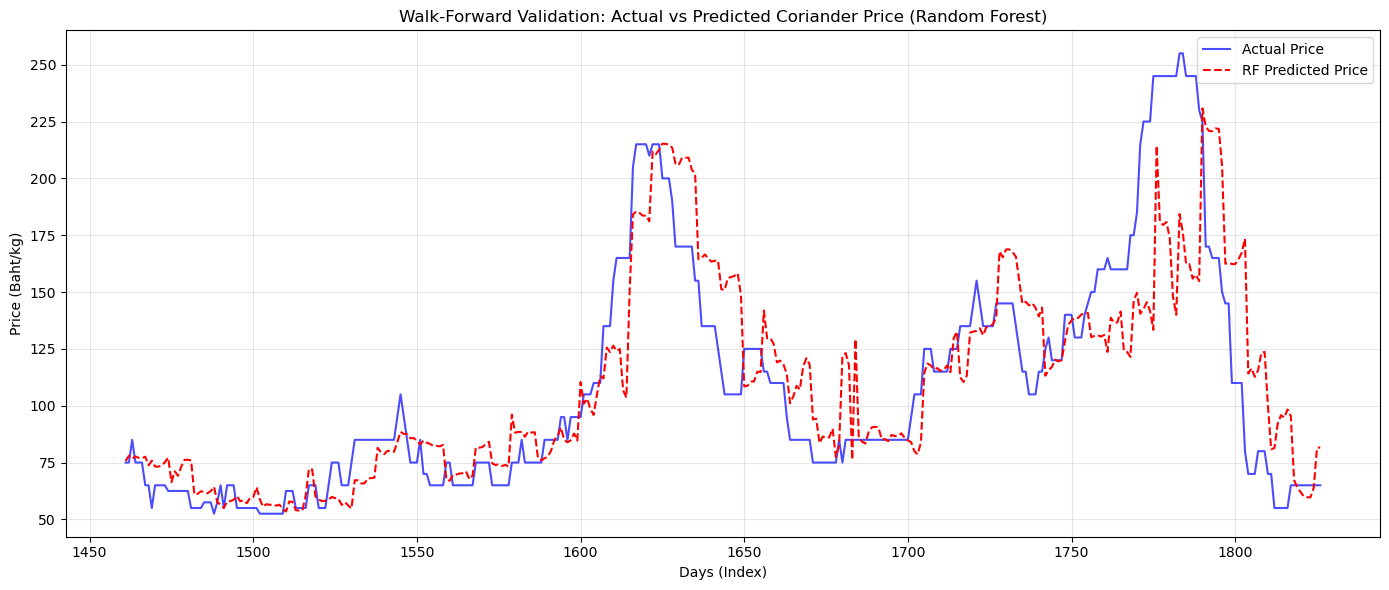

In [36]:
# Cell 5: Model Evaluation

rf_predictions_series = pd.Series(rf_predictions, index=y_test.index)

# Metrics calculation
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions_series))
mae = mean_absolute_error(y_test, rf_predictions_series)
mape = mean_absolute_percentage_error(y_test, rf_predictions_series) * 100

print("=== Random Forest Performance (Coriander) ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue', alpha=0.7)
plt.plot(rf_predictions_series.index, rf_predictions_series.values, label='RF Predicted Price', color='red', linestyle='--')
plt.title('Walk-Forward Validation: Actual vs Predicted Coriander Price (Random Forest)')
plt.xlabel('Days (Index)')
plt.ylabel('Price (Baht/kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_names = X_train.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (RF Model)': importances
})

feature_df = feature_df.sort_values(by='Importance (RF Model)', ascending=False)

feature_df

,Feature,Importance (RF Model)
5,Price_chicken,0.510904
15,Price_spring_onion,0.153113
11,Price_peanut,0.080794
14,Price_shrimp,0.047964
1,Month,0.032738
12,Price_pork,0.023246
21,Avg_Soil_Moisture,0.017942
7,Price_egg,0.016928
6,Price_chili,0.016550
9,Price_lime,0.015028


# Simple RNN

In [12]:
#  Import Deep Learning libraries and build SimpleRNN function
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import os
# Set random seed for reproducibility in Neural Networks
tf.random.set_seed(42)


os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tf.config.set_visible_devices([], 'GPU')


def create_rnn_model(input_shape):
    """
    Creates and compiles a SimpleRNN model for regression.
    """
    model = Sequential()
    
    # SimpleRNN layer: 64 neurons
    model.add(SimpleRNN(64, activation='relu', input_shape=input_shape))
    
    # Dropout layer to prevent overfitting (randomly turns off 20% of neurons)
    model.add(Dropout(0.2))
    
    # Hidden Dense layer to process the RNN output
    model.add(Dense(32, activation='relu'))
    
    # Output layer (1 neuron for predicting the continuous price)
    model.add(Dense(1))
    
    # Compile with Adam optimizer and Mean Squared Error loss
    model.compile(optimizer='adam', loss='mse')
    
    return model

print("SimpleRNN architecture ready.")

SimpleRNN architecture ready.


In [13]:
# Walk-Forward Validation with 7-Day Retraining for SimpleRNN

rnn_predictions = []
retrain_window = 7 

# We need separate scalers for Features (X) and Target (y)
scaler_X_rnn = MinMaxScaler()
scaler_y_rnn = MinMaxScaler()

# Initialize history safely
history_X_rnn = X_train.copy()
# Reshape y to 2D array because MinMaxScaler expects 2D
history_y_rnn = y_train.copy().values.reshape(-1, 1)

print(f"Starting Walk-Forward Validation for SimpleRNN (Retraining every {retrain_window} days)...")
print("Note: This will take a bit longer as it builds and trains a neural network in each step.")

for i in range(0, len(X_test), retrain_window):
    
    # 1. Define the next 7 days to predict
    end_idx = min(i + retrain_window, len(X_test))
    X_test_window = X_test.iloc[i:end_idx]
    y_test_window = y_test.iloc[i:end_idx]
    
    # 2. Scale data based ONLY on current history (Prevent Data Leakage)
    X_train_scaled = scaler_X_rnn.fit_transform(history_X_rnn)
    y_train_scaled = scaler_y_rnn.fit_transform(history_y_rnn)
    
    # Transform test window using the scaler fitted on history
    X_test_scaled = scaler_X_rnn.transform(X_test_window)
    
    # 3. Reshape to 3D for RNN: (samples, timesteps=1, features)
    X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))
    
    # 4. Build and Train the RNN model from scratch for this window
    rnn_model = create_rnn_model(input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))
    rnn_model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=32, verbose=0)
    
    # 5. Predict the next window
    window_preds_scaled = rnn_model.predict(X_test_reshaped, verbose=0)
    
    # 6. Inverse transform the predictions back to actual Baht/kg scale
    window_preds = scaler_y_rnn.inverse_transform(window_preds_scaled)
    rnn_predictions.extend(window_preds.flatten())
    
    # 7. Update historical data for the next iteration
    history_X_rnn = pd.concat([history_X_rnn, X_test_window], ignore_index=True)
    history_y_rnn = np.vstack((history_y_rnn, y_test_window.values.reshape(-1, 1)))
    
    # Optional print to track progress
    if i % 28 == 0 and i > 0:
        print(f"Processed {i} days...")

print("SimpleRNN Forecasting completed.")

Starting Walk-Forward Validation for SimpleRNN (Retraining every 7 days)...
Note: This will take a bit longer as it builds and trains a neural network in each step.
Processed 28 days...
Processed 56 days...
Processed 84 days...
Processed 112 days...
Processed 140 days...
Processed 168 days...
Processed 196 days...
Processed 224 days...
Processed 252 days...
Processed 280 days...
Processed 308 days...
Processed 336 days...
Processed 364 days...
SimpleRNN Forecasting completed.


=== SimpleRNN Performance (Coriander) ===
RMSE : 35.6134
MAE  : 25.3117
MAPE : 22.65%


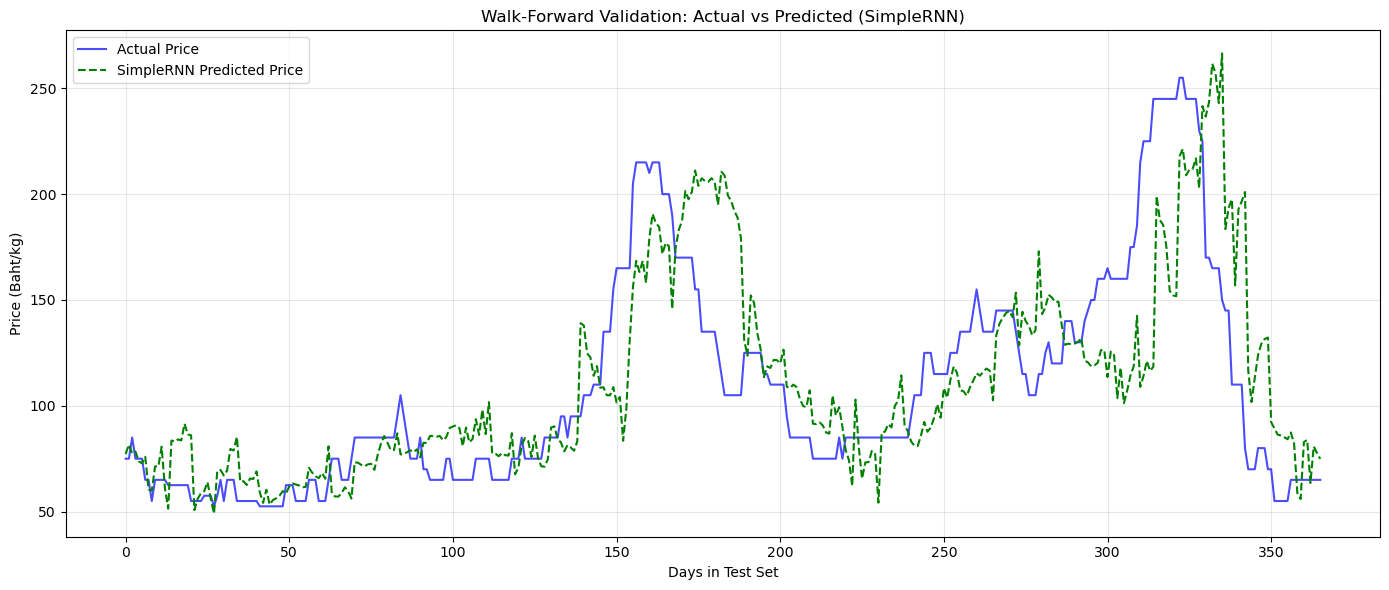

In [14]:
# Evaluation for SimpleRNN

# Convert list to Pandas Series and align the index with y_test
rnn_predictions_series = pd.Series(rnn_predictions, index=y_test.index)

# Calculate Evaluation Metrics
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_predictions_series))
rnn_mae = mean_absolute_error(y_test, rnn_predictions_series)
rnn_mape = mean_absolute_percentage_error(y_test, rnn_predictions_series) * 100

print("=== SimpleRNN Performance (Coriander) ===")
print(f"RMSE : {rnn_rmse:.4f}")
print(f"MAE  : {rnn_mae:.4f}")
print(f"MAPE : {rnn_mape:.2f}%")

# Plot Actual vs SimpleRNN Predicted
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Price', color='blue', alpha=0.7)
plt.plot(rnn_predictions_series.values, label='SimpleRNN Predicted Price', color='green', linestyle='--')
plt.title('Walk-Forward Validation: Actual vs Predicted (SimpleRNN)')
plt.xlabel('Days in Test Set')
plt.ylabel('Price (Baht/kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- Part 0: Convert X_test to 3D (fix X_test_3d is not defined issue) ---
# Check if X_test is a DataFrame; if yes, extract values
if isinstance(X_test, pd.DataFrame):
    X_test_array = X_test.values
else:
    X_test_array = X_test

# Reshape to 3D (num_samples, 1, num_features)
X_test_3d = np.reshape(X_test_array, (X_test_array.shape[0], 1, X_test_array.shape[1]))
print(f"Converted X_test_3d successfully. Shape: {X_test_3d.shape}")

# --- Part 1: Setup and calculate baseline accuracy ---
feature_names = X_train.columns  # Get column names from X_train

# Predict and calculate baseline error
baseline_predictions = rnn_model.predict(X_test_3d, verbose=0)
baseline_mse = mean_squared_error(y_test, baseline_predictions)

importances = []
num_features = X_test_3d.shape[2]

print(f"Baseline MSE: {baseline_mse:.4f}")
print("Calculating Feature Importance. Please wait...\n")

# --- Part 2: Loop through each feature and shuffle ---
for i in range(num_features):
    X_shuffled = X_test_3d.copy()
    
    # Shuffle only the i-th feature
    np.random.shuffle(X_shuffled[:, :, i])
    
    # Predict again
    shuffled_predictions = rnn_model.predict(X_shuffled, verbose=0)
    shuffled_mse = mean_squared_error(y_test, shuffled_predictions)
    
    # Calculate importance
    importance_score = shuffled_mse - baseline_mse
    importances.append(importance_score)

# --- Part 3: Summarize results into a table ---
feature_df_rnn = pd.DataFrame({
    'Feature': feature_names,
    'Importance (MSE Increase)': importances
})

feature_df_rnn = feature_df_rnn.sort_values(by='Importance (MSE Increase)', ascending=False)

print("=== Feature Importance Table (RNN) ===")
feature_df_rnn

Converted X_test_3d successfully. Shape: (366, 1, 22)
Baseline MSE: 60679.1243
Calculating Feature Importance. Please wait...

=== Feature Importance Table (RNN) ===


,Feature,Importance (MSE Increase)
13,Price_shallot,148.037458
6,Price_chili,44.903351
10,Price_onion,31.585716
16,Price_tamarind_juice,22.419184
12,Price_pork,11.143951
0,Day,5.592875
19,Avg_Rainfall_mm,3.088096
17,Important_Days,0.771776
2,Year,0.062247
7,Price_egg,0.032159


# TSLM

In [21]:
# Import Deep Learning libraries and build LSTM function
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Set random seed for reproducibility
tf.random.set_seed(42)

def create_lstm_model(input_shape):
    """
    Creates and compiles an LSTM model for time-series regression.
    """
    model = Sequential()
    
    # LSTM layer: 64 units, designed to capture long-term dependencies
    model.add(LSTM(64, activation='relu', input_shape=input_shape))
    
    # Dropout layer to prevent overfitting
    model.add(Dropout(0.2))
    
    # Hidden Dense layer
    model.add(Dense(32, activation='relu'))
    
    # Output layer (1 neuron for price prediction)
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    
    return model

print("LSTM architecture ready.")

LSTM architecture ready.


In [22]:
# Walk-Forward Validation with 7-Day Retraining for LSTM

lstm_predictions = []
retrain_window = 7 

# Initialize separate scalers
scaler_X_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

# Initialize history safely
history_X_lstm = X_train.copy()
history_y_lstm = y_train.copy().values.reshape(-1, 1)

print(f"Starting Walk-Forward Validation for LSTM (Retraining every {retrain_window} days)...")
print("Note: LSTM usually takes slightly longer to train than SimpleRNN.")

for i in range(0, len(X_test), retrain_window):
    
    # 1. Define the test window
    end_idx = min(i + retrain_window, len(X_test))
    X_test_window = X_test.iloc[i:end_idx]
    y_test_window = y_test.iloc[i:end_idx]
    
    # 2. Fit scaler on CURRENT history and transform
    X_train_scaled = scaler_X_lstm.fit_transform(history_X_lstm)
    y_train_scaled = scaler_y_lstm.fit_transform(history_y_lstm)
    
    # Transform test set strictly using the fitted history scaler
    X_test_scaled = scaler_X_lstm.transform(X_test_window)
    
    # 3. Reshape to 3D for LSTM: (samples, timesteps=1, features)
    X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))
    
    # 4. Build and Train LSTM model
    lstm_model = create_lstm_model(input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]))
    lstm_model.fit(X_train_reshaped, y_train_scaled, epochs=50, batch_size=32, verbose=0)
    
    # 5. Predict the current 7-day window
    window_preds_scaled = lstm_model.predict(X_test_reshaped, verbose=0)
    
    # 6. Inverse transform predictions to original scale
    window_preds = scaler_y_lstm.inverse_transform(window_preds_scaled)
    lstm_predictions.extend(window_preds.flatten())
    
    # 7. Update history for the next iteration (Add the actual true data)
    history_X_lstm = pd.concat([history_X_lstm, X_test_window], ignore_index=True)
    history_y_lstm = np.vstack((history_y_lstm, y_test_window.values.reshape(-1, 1)))
    
    # Progress tracker
    if i % 28 == 0 and i > 0:
        print(f"Processed {i} days...")

print("LSTM Forecasting completed.")

Starting Walk-Forward Validation for LSTM (Retraining every 7 days)...
Note: LSTM usually takes slightly longer to train than SimpleRNN.
Processed 28 days...
Processed 56 days...
Processed 84 days...
Processed 112 days...
Processed 140 days...
Processed 168 days...
Processed 196 days...
Processed 224 days...
Processed 252 days...
Processed 280 days...
Processed 308 days...
Processed 336 days...
Processed 364 days...
LSTM Forecasting completed.


=== LSTM Performance (Coriander) ===
RMSE : 33.9325
MAE  : 23.3542
MAPE : 20.73%


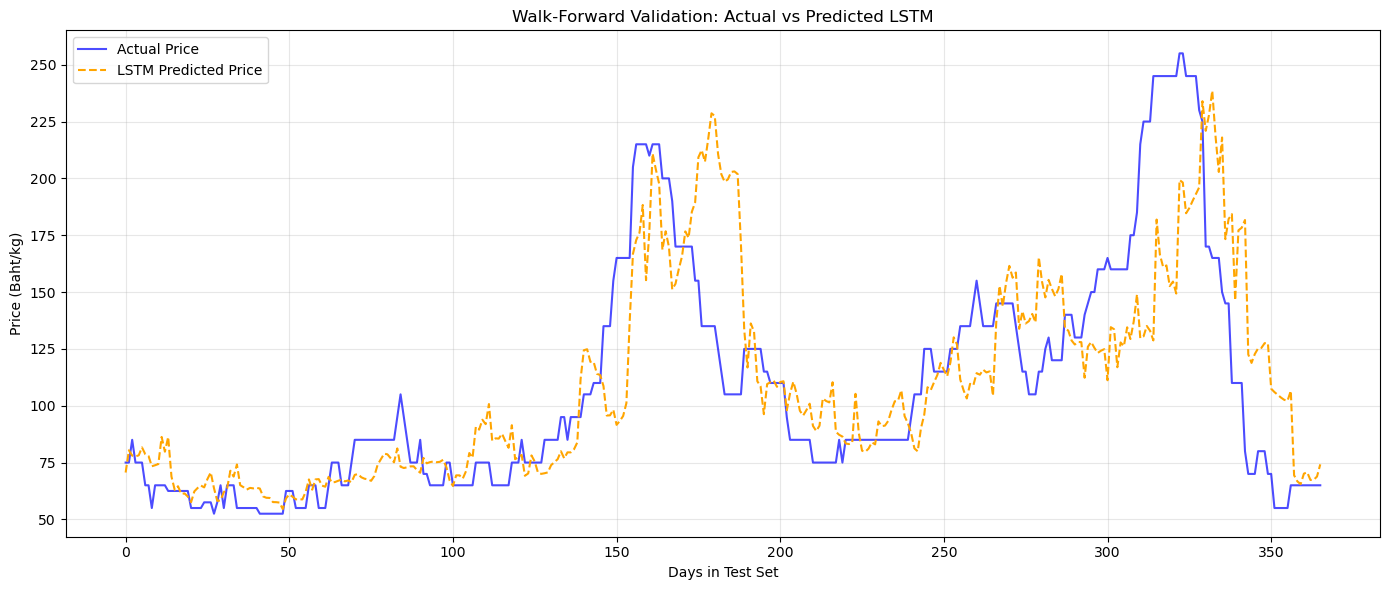

In [23]:
# Evaluation for LSTM

# Convert to Pandas Series
lstm_predictions_series = pd.Series(lstm_predictions, index=y_test.index)

# Calculate Evaluation Metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions_series))
lstm_mae = mean_absolute_error(y_test, lstm_predictions_series)
lstm_mape = mean_absolute_percentage_error(y_test, lstm_predictions_series) * 100

print("=== LSTM Performance (Coriander) ===")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAE  : {lstm_mae:.4f}")
print(f"MAPE : {lstm_mape:.2f}%")


plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Price', color='blue', alpha=0.7)
plt.plot(lstm_predictions_series.values, label='LSTM Predicted Price', color='orange', linestyle='--')
plt.title('Walk-Forward Validation: Actual vs Predicted LSTM')
plt.xlabel('Days in Test Set')
plt.ylabel('Price (Baht/kg)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- Part 0: Convert X_test to 3D (fix X_test_3d is not defined issue) ---
# Check if X_test is a DataFrame; if yes, extract values
if isinstance(X_test, pd.DataFrame):
    X_test_array = X_test.values
else:
    X_test_array = X_test

# Reshape to 3D (num_samples, 1, num_features)
X_test_3d = np.reshape(X_test_array, (X_test_array.shape[0], 1, X_test_array.shape[1]))
print(f"Converted X_test_3d successfully. Shape: {X_test_3d.shape}")

# --- Part 1: Setup and calculate baseline accuracy ---
feature_names = X_train.columns  # Get column names from X_train

# Predict and calculate baseline error
baseline_predictions = lstm_model.predict(X_test_3d, verbose=0)
baseline_mse = mean_squared_error(y_test, baseline_predictions)

importances = []
num_features = X_test_3d.shape[2]

print(f"Baseline MSE: {baseline_mse:.4f}")
print("Calculating Feature Importance. Please wait...\n")

# --- Part 2: Loop through each feature and shuffle ---
for i in range(num_features):
    X_shuffled = X_test_3d.copy()
    
    # Shuffle only the i-th feature
    np.random.shuffle(X_shuffled[:, :, i])
    
    # Predict again
    shuffled_predictions = lstm_model.predict(X_shuffled, verbose=0)
    shuffled_mse = mean_squared_error(y_test, shuffled_predictions)
    
    # Calculate importance
    importance_score = shuffled_mse - baseline_mse
    importances.append(importance_score)

# --- Part 3: Summarize results into a table ---
feature_df_lstm = pd.DataFrame({
    'Feature': feature_names,
    'Importance (MSE Increase)': importances
})

feature_df_lstm = feature_df_lstm.sort_values(by='Importance (MSE Increase)', ascending=False)

print("=== Feature Importance Table (LSTM) ===")
feature_df_lstm

Converted X_test_3d successfully. Shape: (366, 1, 22)
Baseline MSE: 58766.2775
Calculating Feature Importance. Please wait...

=== Feature Importance Table (LSTM) ===


,Feature,Importance (MSE Increase)
16,Price_tamarind_juice,14.696676
18,Avg_Temperature_C,13.077559
4,Diesel,0.809353
21,Avg_Soil_Moisture,0.801864
2,Year,0.056559
11,Price_peanut,0.000000
3,DayOfWeek_Num,-0.127167
9,Price_lime,-0.342217
7,Price_egg,-2.533713
20,Avg_Humidity_Percent,-4.383331


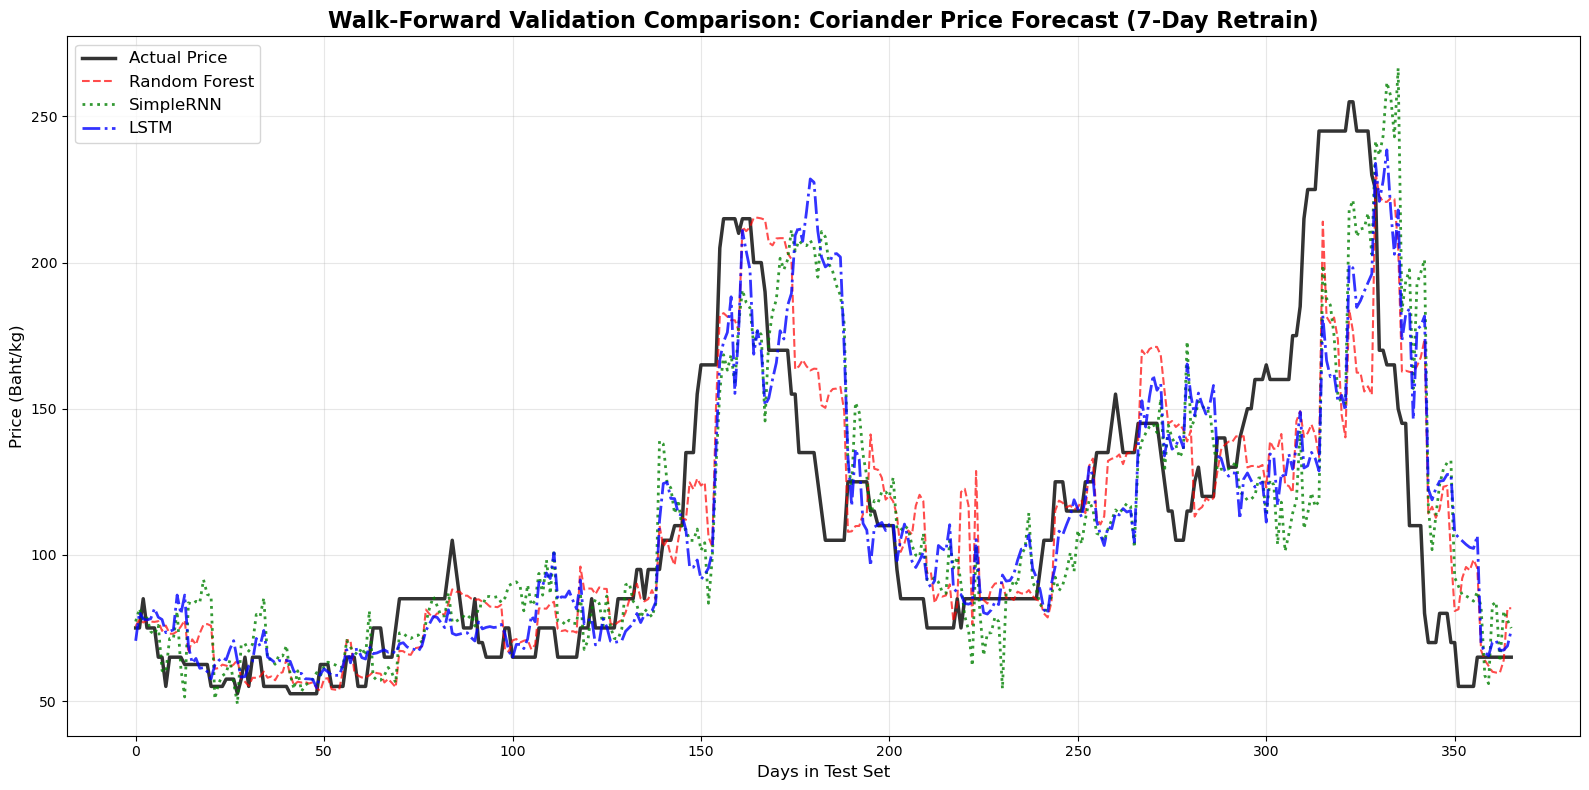

In [26]:
# Cell 12: Combined Plot - Comparing All 3 Models

plt.figure(figsize=(16, 8))

# Plot Actual Data
plt.plot(y_test.values, label='Actual Price', color='black', linewidth=2.5, alpha=0.8)

# Plot Random Forest Predictions
plt.plot(rf_predictions_series.values, label='Random Forest', color='red', linestyle='dashed', alpha=0.7)

# Plot SimpleRNN Predictions
plt.plot(rnn_predictions_series.values, label='SimpleRNN', color='green', linestyle='dotted', alpha=0.8, linewidth=2)

# Plot LSTM Predictions
plt.plot(lstm_predictions_series.values, label='LSTM', color='blue', linestyle='dashdot', alpha=0.8, linewidth=2)

# Graph Formatting
plt.title('Walk-Forward Validation Comparison: Coriander Price Forecast (7-Day Retrain)', fontsize=16, fontweight='bold')
plt.xlabel('Days in Test Set', fontsize=12)
plt.ylabel('Price (Baht/kg)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the ultimate comparison plot!
plt.show()